# **Precision, recall, and F1 score**

Sometimes accuracy can be a bad representative of predicted values, specially when the data is imbalanced.

In some cases, we are more interested in the false positive than false negative. This is bcoz, in some cases accuracy is not the best metric to evaluate the model. For eg. check the image below ;

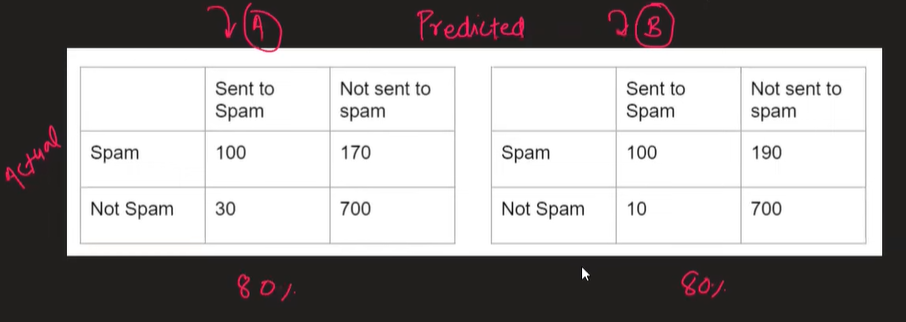

Both the models are giving the same accuracy, but the second model is better than the first model. 

This is bcoz, the second model is giving less false positive than the first model. But the first model is giving less false negative than the second model. Here you have to decide which is more important for you. In this case false positive is more important than the first negative.


**Precision**

Precision is the ratio of true positive to the total predicted positive. This bascially means what proportion of predicted positive values are truely positve.

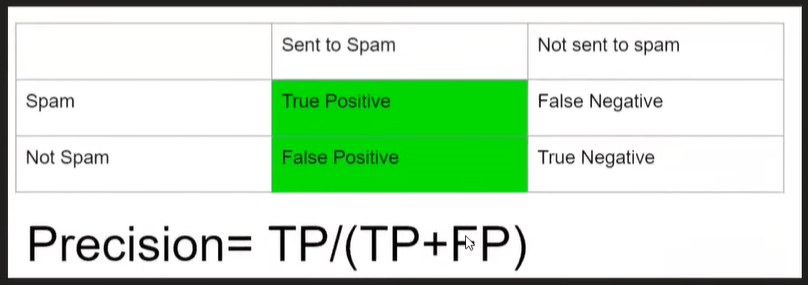


For eg like in the above image of both the models, the precision is  spam / (spam + not spam).

- Model 1 = 100 / (100 + 30) = 0.76 
- Model 2 = 100 / (100 + 10) = 0.9  **(WINNER)**

---

**Recall**

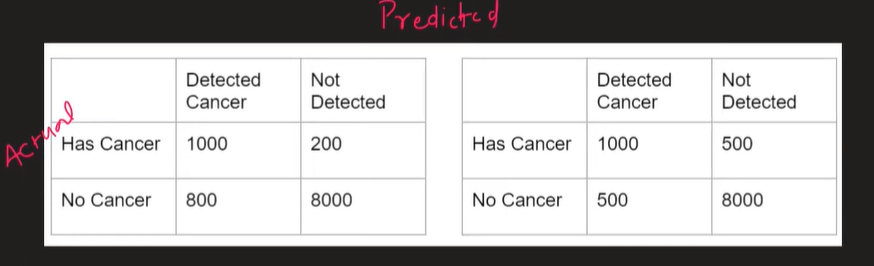

As you can see in the above image, there are two models. Here you cant select the model with highest precision as it will not be a good model. Here rather than going for False Positives, you have to go for False Negatives. Bcoz, it will be quite a severe issue if someone has Cancer and the model failst to detect it.

Although both the models are giving the same 90% accuracy, but you have to go for model 1, coz it has very less false negative.

This is called Recall. 

Recall is the ratio of true positives to the total actual positives. It basically means what proportion of actual positive values are correctly identified by the model.

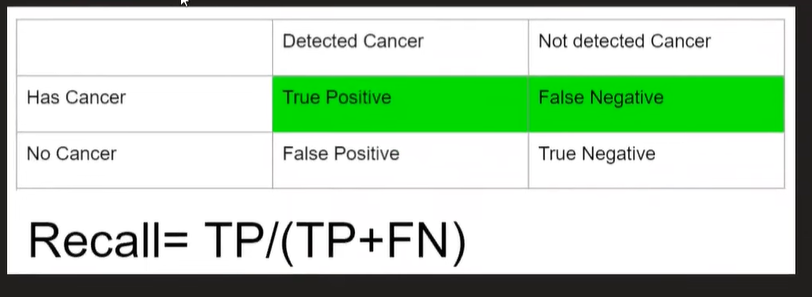

- Model 1 = 1000 / (1000 + 200) = 0.8 **(WINNER)**
- Model 2 = 1000 / (1000 + 500) = 0.6



**F1 Score**

There can be a case where precision and recall are in conflict with each other, which means you will get confused which one to opt for btwn precision and recall. And there comes F1 score, which is the harmonic mean of precision and recall.


While doing f1 score, we do Harmonic mean of precision and recall. Its not like our regular numerical mean / geometric mean. 

The formula for harmonic mean is : 2PR / (P + R)

- P = Precision
- R = Recall


In [1]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, classification_report

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('heart.csv')

df = pd.get_dummies(df, drop_first=True)

df.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160,180,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138,214,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150,195,0,122,0.0,0,True,False,True,False,True,False,False,False,True


In [3]:
X_train, X_test, y_train, y_test = train_test_split(df.drop('HeartDisease', axis=1), df['HeartDisease'], test_size=0.2, random_state=2)

clf1 = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf1.fit(X_train, y_train)
y_pred1 = clf1.predict(X_test)

clf2.fit(X_train, y_train)
y_pred2 = clf2.predict(X_test)

In [4]:
def print_metrics(y_true, y_pred, model_name):
    print(f"--- {model_name} metrics ---")
    print(f"Accuracy : {accuracy_score(y_true, y_pred)}")
    print(f"Precision: {precision_score(y_true, y_pred)}")
    print(f"Recall   : {recall_score(y_true, y_pred)}")
    print(f"F1 Score : {f1_score(y_true, y_pred)}")
    print("\n")

print_metrics(y_test, y_pred1, "Logistic Regression")
print_metrics(y_test, y_pred2, "Decision Tree")

# KEEP IN MIND, F1 score is a little bit biased towards either Precision or Recall whichever has the lower value


--- Logistic Regression metrics ---
Accuracy : 0.8369565217391305
Precision: 0.8155339805825242
Recall   : 0.8842105263157894
F1 Score : 0.8484848484848485


--- Decision Tree metrics ---
Accuracy : 0.7608695652173914
Precision: 0.7931034482758621
Recall   : 0.7263157894736842
F1 Score : 0.7582417582417582


